In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import os
import shutil
import itertools
import pathlib
from PIL import Image

#Data handling tools
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report

#Deep learning libs
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Activation , Dense , Dropout , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras import regularizers

#Warningds
import warnings
warnings.filterwarnings('ignore')

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
# Paths to training and testing datasets
train_dir = 'data_small/Training'
test_dir = 'data_small/Testing'

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
test_datagen = ImageDataGenerator(rescale=1./255)

# Load and preprocess training and testing data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 120 images belonging to 4 classes.
Found 40 images belonging to 4 classes.


In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze layers in the base model
for layer in base_model.layers:
    layer.trainable = False

# Add a global average pooling layer
x = base_model.output
x = GlobalAveragePooling2D()(x)

# Define the model with InceptionV3 features
inception_model = Model(inputs=base_model.input, outputs=x)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
train_features = inception_model.predict(train_generator)
test_features = inception_model.predict(test_generator)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 753ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Reshape
from keras.layers import Bidirectional, LSTM # fix for reproducing and fixing purposes
from tensorflow.keras.models import Model

In [8]:
# --- [CELL 7]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 8}
from tensorflow.keras.utils import to_categorical

# Convert integer labels to one-hot encoding
train_labels_one_hot = to_categorical(train_generator.classes, num_classes=4)
test_labels_one_hot = to_categorical(test_generator.classes, num_classes=4)

In [9]:
# --- [CELL 8]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 9}
from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping criteria
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [10]:
# --- [CELL 9]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 10}
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Reshape, Conv2D, MaxPooling2D, Bidirectional, LSTM, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from kerastuner.tuners import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

In [11]:
# --- [CELL 10]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 11}
# Define the input shape
input_features = Input(shape=(2048,), name='input_features')

# Reshape features to match the expected input shape of the CNN model
reshaped_features = Reshape((32, 64, 1))(input_features)  # Adjust the dimensions based on your features

# CNN layers for feature extraction
cnn_output = Conv2D(32, (3, 3), activation='relu')(reshaped_features)
cnn_output = MaxPooling2D(pool_size=(2, 2))(cnn_output)
cnn_output = Conv2D(64, (3, 3), activation='relu')(cnn_output)
cnn_output = MaxPooling2D(pool_size=(2, 2))(cnn_output)
cnn_output = Conv2D(128, (3, 3), activation='relu')(cnn_output)
cnn_output = MaxPooling2D(pool_size=(2, 2))(cnn_output)
cnn_output = Flatten()(cnn_output)

cnn_output_reshaped = Reshape((1, -1))(cnn_output)

bi_lstm_output = Bidirectional(LSTM(128, return_sequences=True))(cnn_output_reshaped)
bi_lstm_output = Bidirectional(LSTM(64, return_sequences=True))(bi_lstm_output)

# Flatten the output of Bi-LSTM
bi_lstm_output_flatten = Flatten()(bi_lstm_output)

In [12]:
# --- [CELL 11]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 12}
# Hyperparameters tuning
def build_model(hp):
    dense_units = hp.Int('dense_units', min_value=64, max_value=256, step=32)
    lstm_units = hp.Int('lstm_units', min_value=32, max_value=128, step=32)
    dropout_rate = hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)
    optimizer_choice = hp.Choice('optimizer', values=['adam', 'rmsprop', 'sgd'])
    batch_size = hp.Choice('batch_size', values=[16, 32, 64])
    
    if optimizer_choice == 'adam':
        optimizer = Adam(learning_rate=1e-3)
    elif optimizer_choice == 'rmsprop':
        optimizer = RMSprop(learning_rate=1e-3)
    else:
        optimizer = SGD(learning_rate=1e-3)
    dense_layer = Dense(dense_units, activation='relu')(bi_lstm_output_flatten)
    dense_layer = Dropout(dropout_rate)(dense_layer)
    dense_layer = Dense(64, activation='relu')(dense_layer)
    output = Dense(4, activation='softmax')(dense_layer)

    cnn_model = Model(inputs=input_features, outputs=output)
    cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return cnn_model

In [13]:
# --- [CELL 12]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 13}
# Hyperparameter search
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=2, #10,
    directory='hyperparameter_tuning',
    project_name='cnn_model_tuning'
)

# Assuming you already have train_features, test_features, train_labels_one_hot, and test_labels_one_hot
tuner.search(
    train_features, 
    train_labels_one_hot, 
    epochs=2, #50,
    validation_data=(test_features, test_labels_one_hot),
    callbacks=[early_stopping]
)

Reloading Tuner from hyperparameter_tuning/cnn_model_tuning/tuner0.json


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)          │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 32, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_94 (Conv2D)                   │ (None, 30, 62, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 15, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_95 (Conv2D)                   │ (None, 13, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 6, 14, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_96 (Conv2D)                   │ (None, 4, 12, 128)          │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 2, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1536)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_1 (Reshape)                  │ (None, 1, 1536)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 1, 256)              │       1,704,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 1, 128)              │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 192)                 │          24,768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 192)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,999,364 (7.63 MB)

 Trainable params: 1,999,364 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

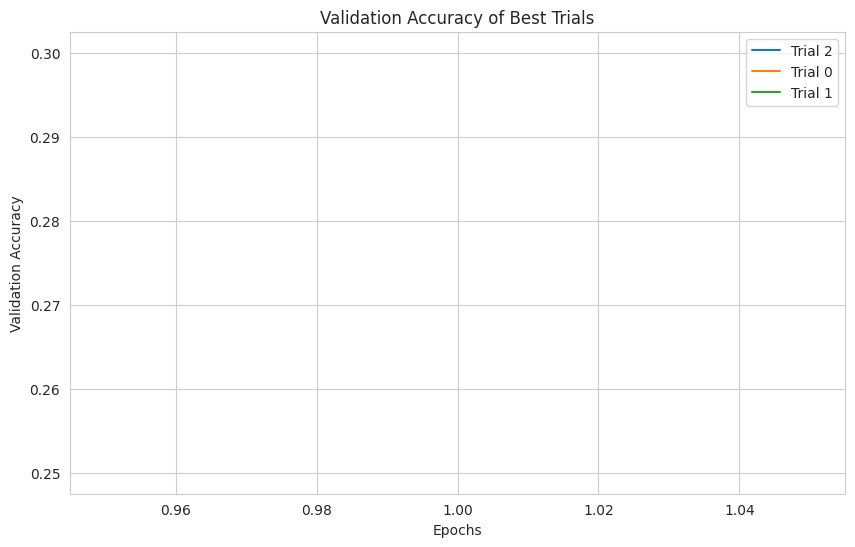

In [14]:
# --- [CELL 13]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 14}
# === BEFORE (original) ===
# # Plot the architecture of the best model
# best_model = tuner.get_best_models(1)[0]
# best_model.summary()
# 
# # Extract information about the best trials
# best_trials = tuner.oracle.get_best_trials(5)
# 
# # Plot the results
# plt.figure(figsize=(10, 6))
# for trial in best_trials:
#     val_accuracy_history = trial.metrics.get_history(name='val_accuracy')
#     plt.plot(val_accuracy_history, label=f'Trial {trial.trial_id}')
# 
# plt.title('Validation Accuracy of Best Trials')
# plt.xlabel('Epochs')
# plt.ylabel('Validation Accuracy')
# plt.legend()
# plt.show()

# === AFTER (edited) ===
best_model = tuner.get_best_models(1)[0]
best_model.summary()

best_trials = tuner.oracle.get_best_trials(5)

plt.figure(figsize=(10, 6))
for trial in best_trials:
    val_accuracy_history = trial.metrics.get_history(name='val_accuracy')
    # Convert MetricObservation objects to floats
    y_vals = [obs.value[0] if isinstance(obs.value, (list, tuple, np.ndarray)) else obs.value
              for obs in val_accuracy_history]
    x_vals = list(range(1, len(y_vals) + 1))
    plt.plot(x_vals, y_vals, label=f'Trial {trial.trial_id}')

plt.title('Validation Accuracy of Best Trials')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

In [1]:
# manual inspection results
if_pass = False
assert if_pass, "Manual inspection failed."

AssertionError: Manual inspection failed.